# Подключение изначальных библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import torch.nn as nn
from google.colab import drive
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

Вход в гугл драйв, где лежит датасет скаченный из Kaggle

In [2]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/go_emotions_dataset.csv'

Mounted at /content/drive


Показ первых 5 строк датасета для демонстрации его содержимого.

In [3]:
emotions_df = pd.read_csv(file_path)
emotions_df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Список всех возможных эмоций встречаемых в данном датасете

In [4]:
list_of_emotions = list(emotions_df.columns)[3:]
print(list_of_emotions)

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


В этом блоке кода мы выполняем предобработку текстовых данных в столбце text датасета emotions_df:
1. Приводим текст к нижнему регистру
2. Удаляем ссылки
3. Убираем HTML-теги
4. Оставляем только английские буквы и пробелы
5. Убираем лишние проблемы

In [5]:
import re

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'<.*?>', '', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  text = ' '.join(text.split())
  return text

emotions_df['text'] = emotions_df['text'].apply(clean_text)
emotions_df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,that game hurt,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,sexuality shouldn t be a grouping category it ...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,you do right if you don t care then fuck em,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,man i love reddit,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,name was nowhere near them he was by the falcon,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Проверяем датасет, чтобы убедиться, что все поля заполнены.

In [6]:
emotions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    211225 non-null  object
 1   text                  211225 non-null  object
 2   example_very_unclear  211225 non-null  bool  
 3   admiration            211225 non-null  int64 
 4   amusement             211225 non-null  int64 
 5   anger                 211225 non-null  int64 
 6   annoyance             211225 non-null  int64 
 7   approval              211225 non-null  int64 
 8   caring                211225 non-null  int64 
 9   confusion             211225 non-null  int64 
 10  curiosity             211225 non-null  int64 
 11  desire                211225 non-null  int64 
 12  disappointment        211225 non-null  int64 
 13  disapproval           211225 non-null  int64 
 14  disgust               211225 non-null  int64 
 15  embarrassment    

Суммирует данные по каждому классу "эмоций", сортируем их по убыванию и визуализируем с помощью Seaborn, добавляя подписи и оформление для наглядности.

/tmp/ipykernel_2699/172708196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")


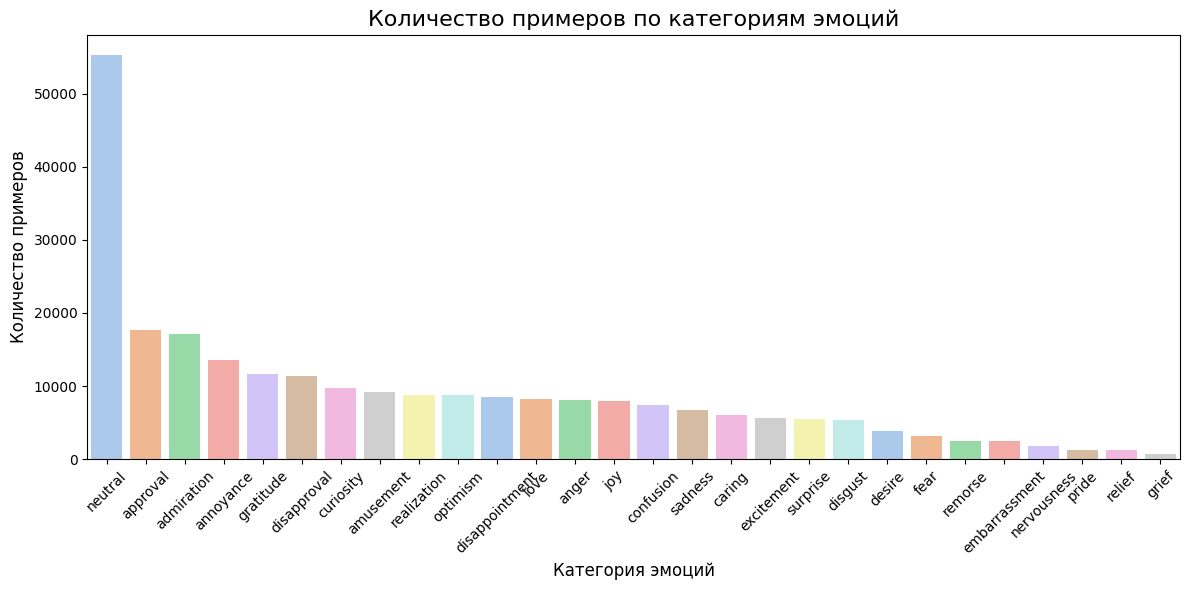

In [7]:
def plot_class_distribution_in_dataset(df, emotion_cols):
  emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)
  plt.figure(figsize=(12,6))
  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")
  plt.title("Количество примеров по категориям эмоций", fontsize=16)
  plt.xlabel("Категория эмоций", fontsize=12)
  plt.ylabel("Количество примеров", fontsize=12)
  plt.xticks(rotation=45)
  plt.tight_layout()

plot_class_distribution_in_dataset(emotions_df, list_of_emotions)

Объединяем исходные эмоции в новые категории согласно заданным группам.

In [8]:
positive = ['admiration', 'amusement', 'approval', 'caring', 'excitement',
  'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief', 'desire']
negative = ['anger', 'annoyance', 'disapproval', 'disgust']
sadness = ['disappointment','embarrassment','grief','remorse','sadness']
cognition = ['confusion','curiosity','realization','surprise']
anxiety = ['fear','nervousness']
neutral = ['neutral']

types_of_emotions = {
  "positive": positive,
  "negative": negative,
  "sadness": sadness,
  "congintion": cognition,
  "anxiety": anxiety,
  "neutral": neutral
}

emotion_to_type = {}
for category, emotions in types_of_emotions.items():
  for emo in emotions:
    emotion_to_type[emo] = category

for category, emotions in types_of_emotions.items():
  emotions_df[category] = emotions_df[emotions].sum(axis=1)
  emotions_df[category] = emotions_df[category].apply(lambda x: 1 if x > 0 else 0)

delete_emotions_list = [e for e in list_of_emotions if e not in ["neutral", "sadness"]]
emotions_df = emotions_df.drop(columns=delete_emotions_list)
emotions_df = emotions_df[emotions_df['example_very_unclear'] == False]
emotions_df = emotions_df.drop(columns=['id', 'example_very_unclear'])
emotions_df.head()

,text,sadness,neutral,positive,negative,congintion,anxiety
0,that game hurt,1,0,0,0,0,0
2,you do right if you don t care then fuck em,0,1,0,0,0,0
3,man i love reddit,0,0,1,0,0,0
4,name was nowhere near them he was by the falcon,0,1,0,0,0,0
5,right considering it s such an important docum...,0,0,1,0,0,0


Проверяем датасет

In [9]:
emotions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207814 entries, 0 to 211223
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        207814 non-null  object
 1   sadness     207814 non-null  int64 
 2   neutral     207814 non-null  int64 
 3   positive    207814 non-null  int64 
 4   negative    207814 non-null  int64 
 5   congintion  207814 non-null  int64 
 6   anxiety     207814 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 12.7+ MB


Демонстрация распределения классов

/tmp/ipykernel_2699/172708196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="pastel")


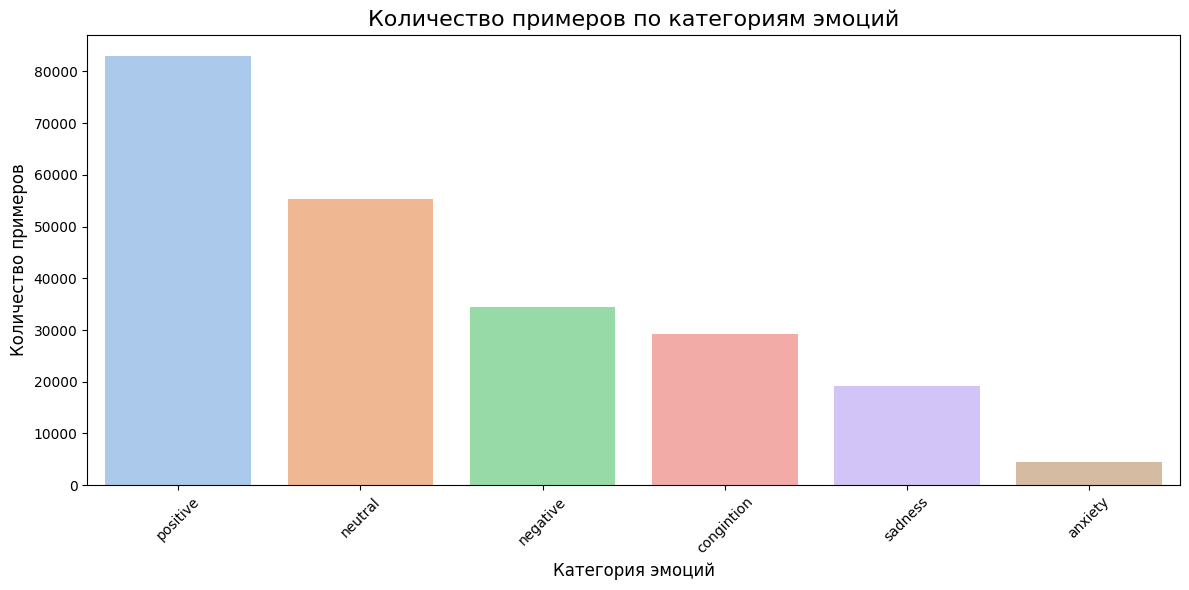

In [10]:
crt_emotions = list(emotions_df.columns)[1:]
plot_class_distribution_in_dataset(emotions_df, crt_emotions)

Создание класса для датасета

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class GoEmotionDataset(Dataset):
  def __init__(self, dataframe, tokenizer, max_len, label_columns):
    self.df = dataframe
    self.tokenizer = tokenizer
    self.max_len = max_len
    self.label_columns = label_columns

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    text = self.df.iloc[idx]['text']
    labels = self.df.iloc[idx][self.label_columns].values.astype(np.float32)
    encoded = self.tokenizer(
      text,
      add_special_tokens=True,
      max_length=self.max_len,
      padding='max_length',
      truncation=True,
      return_attention_mask=True,
      return_tensors='pt'
    )

    input_ids = encoded['input_ids'].squeeze(0)
    label_tensor = torch.tensor(labels, dtype=torch.float)
    attention_mask = encoded['attention_mask'].squeeze(0)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': label_tensor
    }

In [12]:
from transformers import BertModel, BertTokenizer


train_emotions, temp_emotions = train_test_split(emotions_df, test_size=0.3, random_state=42)
val_emotions, test_emotions = train_test_split(temp_emotions, test_size=0.5, random_state=24)

MAX_LEN = 32
bert_model_name = 'bert-base-uncased'
bert_model = BertModel.from_pretrained(bert_model_name)
tokenizer = BertTokenizer.from_pretrained(bert_model_name)

pretrained_embeddings = bert_model.embeddings.word_embeddings.weight.data
vocab_size, embed_dim = pretrained_embeddings.size()

print(f"Vocabulary size from BERT: {vocab_size}, Embedding dimension: {embed_dim}")
label_columns = ['sadness','neutral','positive','negative','congintion','anxiety']

train_dataset = GoEmotionDataset(
  dataframe=train_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

val_dataset = GoEmotionDataset(
  dataframe=val_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

test_dataset = GoEmotionDataset(
  dataframe=test_emotions,
  tokenizer=tokenizer,
  max_len=MAX_LEN,
  label_columns=label_columns
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size from BERT: 30522, Embedding dimension: 768


In [13]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(label_columns)}")
VOCAB_SIZE = tokenizer.vocab_size
print(f"Vacabulary size: {VOCAB_SIZE}")

Training samples: 145469
Validation samples: 31172
Test samples: 31173
Number of classes: 6
Vacabulary size: 30522


Создание модели на основе BiLSTM архитектуры

In [14]:
import torch.optim as optim

class BiLSTMClassifier(nn.Module):
  def __init__(self, pretrained_embeddings, hidden_dim, num_layers, num_classes, dropout_rate=0.5):
    super(BiLSTMClassifier, self).__init__()

    self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)
    embed_dim = pretrained_embeddings.size(1)

    self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                        batch_first=True, bidirectional=True,
                        dropout=dropout_rate)

    self.attention = nn.Linear(hidden_dim * 2, 1)

    self.dropout = nn.Dropout(dropout_rate)
    self.fc = nn.Linear(hidden_dim * 2, num_classes)

  def forward(self, x):
    embedded = self.embedding(x)
    lstm_out, _ = self.lstm(embedded)

    attn_weights = self.attention(lstm_out)
    attn_weights = torch.softmax(attn_weights, dim=1)

    context_vector = torch.sum(attn_weights * lstm_out, dim=1)

    last_hidden = self.dropout(context_vector)
    output = self.fc(last_hidden)
    return output


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 256
NUM_LAYERS = 3
model = BiLSTMClassifier(
    pretrained_embeddings=pretrained_embeddings,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(label_columns)
).to(device)

LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=2e-5)

Обучение модели

In [15]:
from tqdm.auto import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

pos_counts = train_emotions[label_columns].sum().values
total_counts = len(train_emotions)
pos_weights = (total_counts - pos_counts) / pos_counts
print(pos_weights)
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)
print(pos_weights_tensor)


optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

best_val_f1 = 0.0
patience = 2
patience_counter = 0
EPOCHS = 7

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 10)

    model.train()
    total_train_loss = 0
    train_bar = tqdm(train_loader, desc="Training")

    for batch in train_bar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        output = model(input_ids)

        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Average training loss: {avg_train_loss:.4f}")

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_targets =[]

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validating")
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            output = model(input_ids)

            loss = criterion(output, labels)
            total_val_loss += loss.item()

            probs = torch.sigmoid(output)

            predictions = (probs > 0.5).int()

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            val_bar.set_postfix({'val_loss': f"{loss.item():.4f}"})

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Average validation loss: {avg_val_loss:.4f}")

    val_f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation F1 macro (Threshold 0.5): {val_f1_macro:.4f}")
    val_precision_macro = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation Precision macro: {val_precision_macro:.4f}")

    val_recall_macro = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    print(f"Validation Recall macro: {val_recall_macro:.4f}")

    val_precision_per_class = precision_score(all_targets, all_preds, average=None, zero_division=0)
    val_recall_per_class = recall_score(all_targets, all_preds, average=None, zero_division=0)
    val_f1_per_class = f1_score(all_targets, all_preds, average=None, zero_division=0)
    for idx, label in enumerate(label_columns):
      print(f"{label}: Precision={val_precision_per_class[idx]:.4f}, Recall={val_recall_per_class[idx]:.4f}, F1={val_f1_per_class[idx]:.4f}")

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'val_f1_macro': val_f1_macro,
        }, 'best_emotion_model.pth')
        print("Best model saved!")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

[ 9.8802543   2.75287653  1.50407106  5.06146089  6.10159149 45.20997459]
tensor([ 9.8803,  2.7529,  1.5041,  5.0615,  6.1016, 45.2100], device='cuda:0')

Epoch 1/7
----------


Training:   0%|          | 0/2273 [00:00<?, ?it/s]

Average training loss: 0.9999


Validating:   0%|          | 0/488 [00:00<?, ?it/s]

Average validation loss: 0.9176
Validation F1 macro (Threshold 0.5): 0.4059
Validation Precision macro: 0.3183
Validation Recall macro: 0.6994
sadness: Precision=0.2293, Recall=0.7197, F1=0.3478
neutral: Precision=0.3935, Recall=0.6753, F1=0.4973
positive: Precision=0.6917, Recall=0.7140, F1=0.7027
negative: Precision=0.3144, Recall=0.6972, F1=0.4334
congintion: Precision=0.1932, Recall=0.6489, F1=0.2977
anxiety: Precision=0.0875, Recall=0.7413, F1=0.1565
Best model saved!

Epoch 2/7
----------


...

Average validation loss: 0.9265
Validation F1 macro (Threshold 0.5): 0.4620
Validation Precision macro: 0.3699
Validation Recall macro: 0.7058
sadness: Precision=0.2412, Recall=0.7431, F1=0.3642
neutral: Precision=0.4418, Recall=0.6574, F1=0.5285
positive: Precision=0.7178, Recall=0.7463, F1=0.7317
negative: Precision=0.3587, Recall=0.7933, F1=0.4941
congintion: Precision=0.3241, Recall=0.6288, F1=0.4277
anxiety: Precision=0.1360, Recall=0.6657, F1=0.2258
No improvement. Patience: 1/2

Epoch 7/7
----------


Training:   0%|          | 0/2273 [00:00<?, ?it/s]

Average training loss: 0.6637


Validating:   0%|          | 0/488 [00:00<?, ?it/s]

Average validation loss: 0.9151
Validation F1 macro (Threshold 0.5): 0.4546
Validation Precision macro: 0.3660
Validation Recall macro: 0.7074
sadness: Precision=0.2396, Recall=0.7633, F1=0.3647
neutral: Precision=0.4358, Recall=0.6618, F1=0.5255
positive: Precision=0.7186, Recall=0.7382, F1=0.7283
negative: Precision=0.3802, Recall=0.7475, F1=0.5040
congintion: Precision=0.3184, Recall=0.6391, F1=0.4250
anxiety: Precision=0.1034, Recall=0.6944, F1=0.1800
No improvement. Patience: 2/2
Early stopping triggered.


Сохранение параметров и весов после обучения

In [16]:
import pickle
from pathlib import Path
import shutil


export_dir = Path("/content/export_model")
export_dir.mkdir(exist_ok=True)

embedding_matrix = None
if hasattr(model, 'embedding'):
    embedding_matrix = model.embedding.weight.data.cpu().numpy()

model_params = {
    'vocab_size': VOCAB_SIZE,
    'embed_dim': embed_dim,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'num_classes': len(label_columns),
    'max_len': MAX_LEN,
    'label_columns': label_columns,
    'embedding_matrix': embedding_matrix
}

with open(export_dir / 'model_params.pkl', 'wb') as f:
    pickle.dump(model_params, f)

tokenizer.save_pretrained(export_dir / 'saved_tokenizer')

print(f"All files have been successfully saved in '{export_dir}'")

shutil.make_archive('/content/export_model', 'zip', export_dir)
print("Zip archive created: /content/export_model.zip")


All files have been successfully saved in '/content/export_model'
Zip archive created: /content/export_model.zip
